In [ ]:
%%writefile my_dtp_script.py
from bs4 import BeautifulSoup
import requests
import pandas as pd
from datetime import datetime, timedelta
from geopy.geocoders import Nominatim, Yandex
from sqlalchemy import create_engine, inspect
import time
import json

import warnings
warnings.filterwarnings("ignore")

# ---------- НАСТРОЙКИ ----------
region_id = "03"          # Краснодарский край
region_name = "Краснодарский край"
district_id = "03420"     # Краснодар
year = 2024
month = 1
cities_23 = ['Краснодар', 'Сочи', 'Новороссийск', 'Армавир']

# ---------- ФУНКЦИИ ----------
def parse_cities_wiki(url=None, headers=None, timeout=10):
    """
    Парсит список городов России с Wikipedia и возвращает DataFrame.
    """
    if url is None:
        url = "https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%BE%D0%B2_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8"
    if headers is None:
        headers = {'User-Agent': 'Mozilla/5.0'}

    try:
        response = requests.get(url, headers=headers, timeout=timeout)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при загрузке страницы: {e}")
        return pd.DataFrame()

    soup = BeautifulSoup(response.content, 'html.parser')
    rows = soup.find_all('tr')
    data = []

    for row in rows:
        cells = row.find_all('td')
        if len(cells) >= 6:
            city_name = cells[2].find('a').text if cells[2].find('a') else ''
            region_name_cell = cells[3].find('a').text if cells[3].find('a') else ''
            federal_district = cells[4].text.strip() if len(cells) > 4 else ''
            population = cells[5].get('data-sort-value', '')
            data.append({
                "Город": city_name,
                "Регион": region_name_cell,
                "Федеральный_округ": federal_district,
                "Население": population
            })

    return pd.DataFrame(data)


def add_coordinates(df, city_column='Город', api_key=None, user_agent='Mozilla/5.0', delay=1):
    """
    Добавляет координаты (широту и долготу) к датафрейму с городами.
    """
    if api_key is None:
        raise ValueError("Необходимо указать API-ключ для Яндекс.Геокодера.")

    geolocator = Yandex(user_agent=user_agent, timeout=10, api_key=api_key)
    result_df = df.copy()
    latitudes = []
    longitudes = []

    for city in result_df[city_column]:
        try:
            location = geolocator.geocode(city)
            if location:
                latitudes.append(location.latitude)
                longitudes.append(location.longitude)
            else:
                latitudes.append(None)
                longitudes.append(None)
        except Exception as e:
            print(f"Ошибка при геокодировании города '{city}': {e}")
            latitudes.append(None)
            longitudes.append(None)
        time.sleep(delay)

    result_df['Широта'] = latitudes
    result_df['Долгота'] = longitudes
    return result_df


def get_archive_data(latitude=None, longitude=None, start_date='2024-01-01',
                     end_date='2024-12-31', locations_df=None):
    """
    Загрузка погодных данных из Open-Meteo API.
    """
    def _get_single_location(lat, lon, start, end):
        url = "url_open-meteo"
        params = {
            "latitude": lat,
            "longitude": lon,
            "hourly": "temperature_2m,precipitation",
            "start_date": start,
            "end_date": end,
            "timezone": "auto"
        }
        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            data = response.json()
            df = pd.DataFrame({
                "Дата": data["hourly"]["time"],
                "Температура": data["hourly"]["temperature_2m"],
                "Осадки": data["hourly"]["precipitation"]
            })
            df["Широта"] = lat
            df["Долгота"] = lon
            df["Дата"] = pd.to_datetime(df["Дата"])
            return df
        except Exception as e:
            print(f"Ошибка для ({lat}, {lon}): {e}")
            return None

    if locations_df is not None:
        all_weather = []
        for _, row in locations_df.iterrows():
            wdf = _get_single_location(row['Широта'], row['Долгота'], start_date, end_date)
            if wdf is not None:
                if 'Город' in locations_df.columns:
                    wdf['Город'] = row['Город']
                if 'Население' in locations_df.columns:
                    wdf['Население'] = row['Население']
                all_weather.append(wdf)
        if all_weather:
            return pd.concat(all_weather, ignore_index=True)
        else:
            print("Не удалось загрузить погоду ни для одной локации")
            return None
    elif latitude is not None and longitude is not None:
        return _get_single_location(latitude, longitude, start_date, end_date)
    else:
        raise ValueError("Укажите latitude и longitude или locations_df")


def get_dtp_cards(region_id, district_id, year, month, start=1, end=100):
    """Получение карточек ДТП с пагинацией"""
    url = "url_DTP"
    payload = {
        "data": {
            "date": [f"MONTHS:{month}.{year}"],
            "ParReg": region_id,
            "order": {"type": "1", "fieldName": "dat"},
            "reg": district_id,
            "ind": "1",
            "st": str(start),
            "en": str(end),
            "fil": {"isSummary": False},
            "fieldNames": [
                "dat", "time", "coordinates", "infoDtp", "k_ul", "dor", "ndu",
                "k_ts", "ts_info", "pdop", "pog", "osv", "s_pch", "s_pog",
                "n_p", "n_pg", "obst", "sdor", "t_osv", "t_p", "t_s", "v_p", "v_v"
            ]
        }
    }
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept": "application/json",
        "Content-Type": "application/json"
    }
    try:
        request_data = {"data": json.dumps(payload["data"], separators=(',', ':'))}
        response = requests.post(url, json=request_data, headers=headers, timeout=30)
        if response.status_code == 200:
            response_data = json.loads(response.text)
            return json.loads(response_data["data"]).get("tab", [])
        else:
            print(f"HTTP {response.status_code} для района {district_id}, месяц {month}")
            return None
    except Exception as e:
        print(f"Ошибка: {e}")
        return None


def collect_dtp_data(region_id, district_ids, year, months=range(1, 13)):
    """Собирает данные ДТП за указанные районы и месяцы"""
    all_dtp = []
    for d_id in district_ids:
        for month in months:
            print(f"Загружаю район {d_id}, месяц {month}.{year}")
            data = get_dtp_cards(region_id, d_id, year, month)
            if data:
                for record in data:
                    record['region'] = region_id
                    record['district_id'] = d_id
                    record['year'] = year
                    record['month'] = month
                all_dtp.extend(data)
            time.sleep(0.5)
    return all_dtp


def transform_dtp_to_rows(dtp_list):
    """Преобразует сырые данные ДТП в плоский DataFrame с полом участников"""
    rows = []
    for dtp in dtp_list:
        base = {
            'Дата': dtp.get('date'),
            'Время': dtp.get('Time'),
            'Город': dtp.get('District', '').replace('Г.', '').replace(' (Район)', '').strip().title(),
            'Вид_ДТП': dtp.get('DTP_V'),
            'Погибло': dtp.get('POG'),
            'Ранено': dtp.get('RAN'),
            'COORD_W': dtp.get('infoDtp', {}).get('COORD_W'),
            'COORD_L': dtp.get('infoDtp', {}).get('COORD_L')
        }
        # Участники из ts_info
        for ts in dtp.get('infoDtp', {}).get('ts_info', []):
            for part in ts.get('ts_uch', []):
                row = base.copy()
                row['Пол'] = part.get('POL')
                rows.append(row)
        # Участники из uchInfo
        for part in dtp.get('infoDtp', {}).get('uchInfo', []):
            row = base.copy()
            row['Пол'] = part.get('POL')
            rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df['Дата_время'] = pd.to_datetime(df['Дата'] + ' ' + df['Время'], errors='coerce')
    df['Дата_час'] = df['Дата_время'].dt.floor('H')
    return df


# ---------- ФУНКЦИИ СОХРАНЕНИЯ В SQLITE ----------
def save_to_sqlite(df, db_path, table_name, if_exists='replace'):
    """Универсальное сохранение DataFrame в SQLite"""
    engine = create_engine(f'sqlite:///{db_path}')
    try:
        df.to_sql(table_name, con=engine, if_exists=if_exists, index=False)
        print(f"Сохранено {len(df)} записей в таблицу '{table_name}' (БД: {db_path})")
    except Exception as e:
        print(f"Ошибка сохранения в {table_name}: {e}")


# ---------- ОСНОВНОЙ БЛОК ----------
if __name__ == '__main__':
    # 1. Города и координаты
    print("Загрузка списка городов...")
    cities = parse_cities_wiki()
    # Для теста берём 4 городa (иначе слишком много запросов к геокодеру)
    sample_cities = cities[cities['Город'].isin(cities_23)]
    print("Добавление координат...")
    full_cities = add_coordinates(
        df=sample_cities,
        city_column='Город',
        api_key='ваш ключ',  # ваш ключ
        delay=1
    )
    save_to_sqlite(full_cities, 'russian_cities.db', 'cities')

    # 2. Погодные данные для этих городов
    print("Загрузка архивной погоды...")
    weather_data = get_archive_data(locations_df=full_cities)
    if weather_data is not None and not weather_data.empty:
        save_to_sqlite(weather_data, 'russian_cities.db', 'weather')

    # 3. Данные ДТП
    print("Сбор данных ДТП...")
    district_list = ['03401', '03405', '03420', '03426']   # нужные районы
    raw_dtp = collect_dtp_data(region_id, district_list, year, months=range(1, 13))
    print(f"Получено {len(raw_dtp)} карточек ДТП")
    dtp_df = transform_dtp_to_rows(raw_dtp)
    if not dtp_df.empty:
        save_to_sqlite(dtp_df, 'russian_cities.db', 'dtp')
    else:
        print("Нет данных ДТП для сохранения")

    # Вывод информации о полученных данных
    print("\n=== СТАТИСТИКА ===")
    print(f"Городов с координатами: {len(full_cities)}")
    print(f"Записей погоды: {len(weather_data) if weather_data is not None else 0}")
    print(f"Записей ДТП (участников): {len(dtp_df)}")

Overwriting my_dtp_script.py


In [9]:
!python my_dtp_script.py

Загрузка списка городов...
Добавление координат...
Сохранено 4 записей в таблицу 'cities' (БД: russian_cities.db)
Загрузка архивной погоды...
Сохранено 35136 записей в таблицу 'weather' (БД: russian_cities.db)
Сбор данных ДТП...
Загружаю район 03401, месяц 1.2024
Загружаю район 03401, месяц 2.2024
Загружаю район 03401, месяц 3.2024
Загружаю район 03401, месяц 4.2024
Загружаю район 03401, месяц 5.2024
Загружаю район 03401, месяц 6.2024
Загружаю район 03401, месяц 7.2024
Загружаю район 03401, месяц 8.2024
Загружаю район 03401, месяц 9.2024
Загружаю район 03401, месяц 10.2024
Загружаю район 03401, месяц 11.2024
Загружаю район 03401, месяц 12.2024
Загружаю район 03405, месяц 1.2024
Загружаю район 03405, месяц 2.2024
Загружаю район 03405, месяц 3.2024
Загружаю район 03405, месяц 4.2024
Загружаю район 03405, месяц 5.2024
Загружаю район 03405, месяц 6.2024
Загружаю район 03405, месяц 7.2024
Загружаю район 03405, месяц 8.2024
Загружаю район 03405, месяц 9.2024
Загружаю район 03405, месяц 10.20

In [12]:
from sqlalchemy import create_engine, text
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

engine = create_engine('sqlite:///russian_cities.db')

In [11]:
df_dtp = pd.read_sql('select * from dtp', con=engine, parse_dates= ['Дата_время', 'Дата_час'])

df_weather = pd.read_sql('select * from weather', con=engine, parse_dates= ['Дата'])
df_weather = df_weather.rename(columns= {'Дата': 'Дата_час'})

merged = pd.merge(df_dtp[['Дата_время', 'Дата_час', 'Город', 'Вид_ДТП',	'Погибло', 'Ранено', 'Пол', 'COORD_W',	'COORD_L']], 
                  df_weather[['Дата_час', 'Город', 'Температура', 'Осадки', 'Население']], 
                  on= ['Дата_час', 'Город'], how='left')

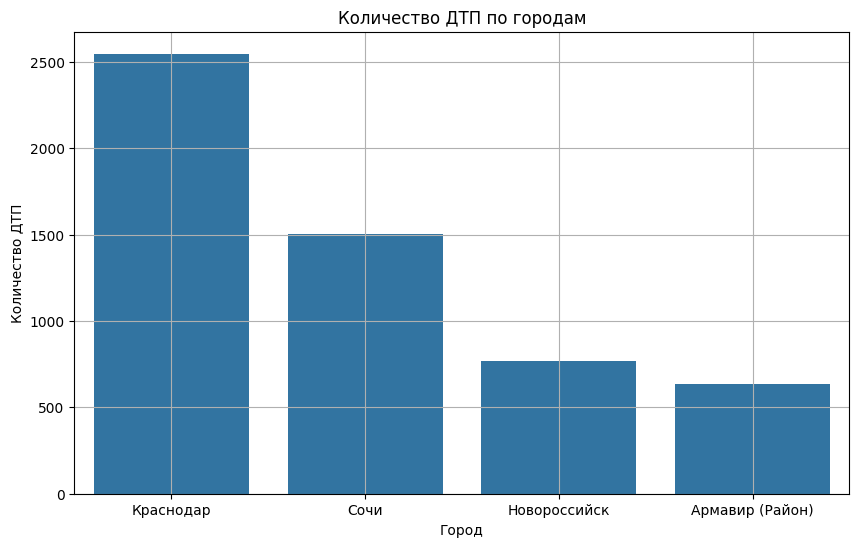

In [ ]:
plt.figure(figsize=(10,6))

city_counts = merged['Город'].value_counts()

sns.barplot(x=city_counts.index, y=city_counts.values)

plt.title('Количество ДТП по городам')
plt.xlabel('Город')
plt.ylabel('Количество ДТП')

plt.grid()
plt.show()

Столбчатая диаграмма, показывающая общее количество ДТП в каждом городе. Позволяет сравнить частоту происшествий между разными населёнными пунктами.


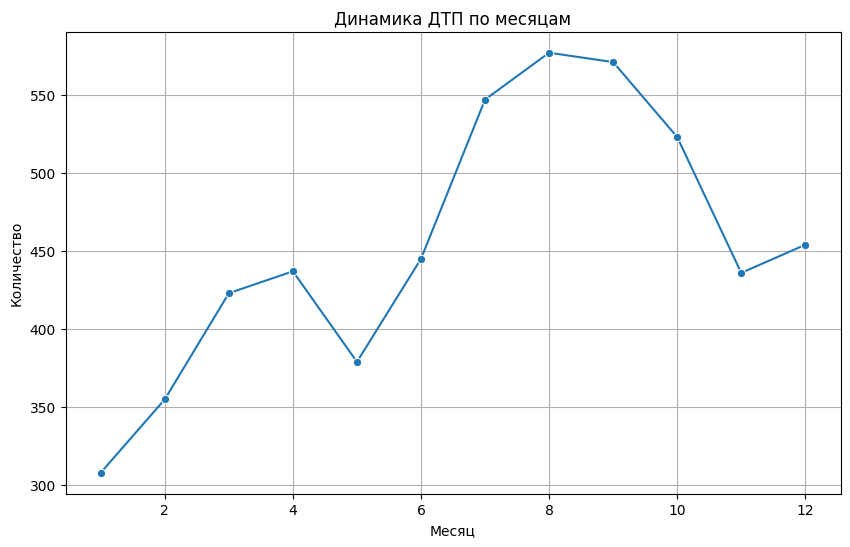

In [ ]:
merged['Месяц'] = merged['Дата_время'].dt.month
month_counts = merged['Месяц'].value_counts().sort_index()

plt.figure(figsize=(10,6))

sns.lineplot(x=month_counts.index, y=month_counts.values, marker= 'o')

plt.title('Динамика ДТП по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')

plt.grid()
plt.show()

Линейный график с маркерами, отображающий количество ДТП в каждом месяце. Выявляет сезонные колебания аварийности (например, рост зимой или летом).


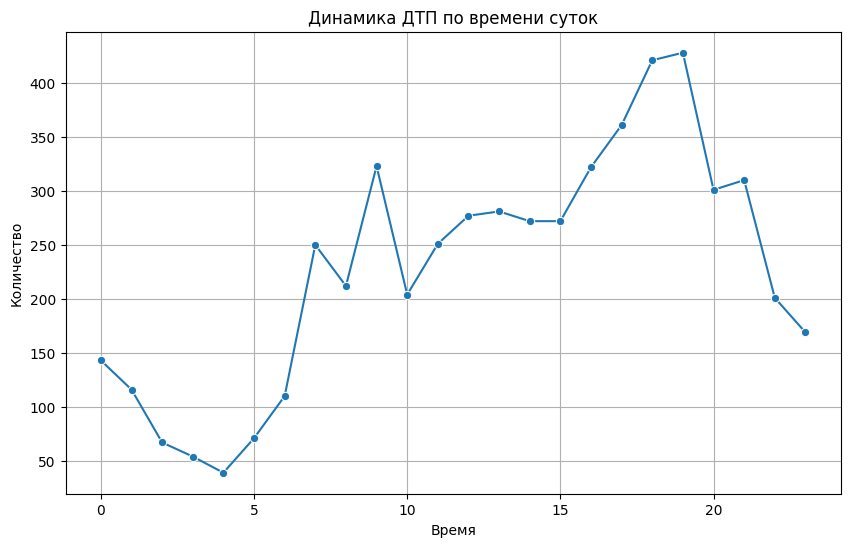

In [ ]:
merged['Час'] = merged['Дата_время'].dt.hour
hour_counts = merged['Час'].value_counts().sort_index()

plt.figure(figsize=(10,6))

sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker= 'o')

plt.title('Динамика ДТП по времени суток')
plt.xlabel('Время')
plt.ylabel('Количество')

plt.grid()
plt.show()

Аналогичный линейный график по часам суток. Помогает определить часы пик, когда происходит больше всего ДТП.


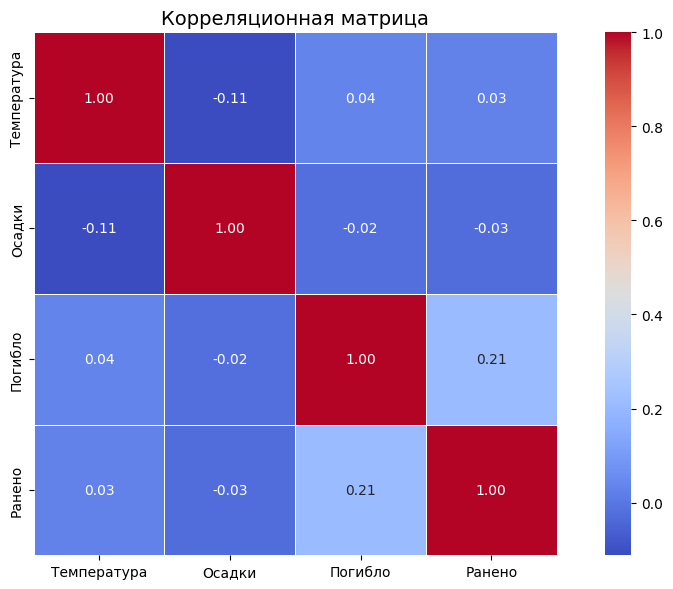

In [ ]:
correlation_matrix = merged[['Температура', 'Осадки', 'Погибло', 'Ранено']].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix,
            annot=True,           
            fmt='.2f',           
            cmap='coolwarm',     
            linewidths=0.5,       
            square=True)          

plt.title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.show()

Тепловая карта, показывающая корреляции между температурой, осадками, числом погибших и раненых. Оценивает взаимосвязи погоды и последствий аварий.


In [ ]:
dtp_by_weather = merged.groupby(['Вид_ДТП', pd.cut(merged['Температура'], bins=5)]).size().unstack()
dtp_by_weather

Температура,"(-10.249, -0.46]","(-0.46, 9.28]","(9.28, 19.02]","(19.02, 28.76]","(28.76, 38.5]"
Вид_ДТП,,,,,
Иной вид ДТП,0,4,1,0,0
Наезд на велосипедиста,0,14,33,37,18
Наезд на внезапно возникшее препятствие,0,0,4,3,0
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность",0,0,0,1,0
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы",0,5,0,2,2
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ",0,3,2,0,0
Наезд на пешехода,20,367,436,388,119
Наезд на препятствие,0,30,60,50,12
Наезд на стоящее ТС,18,24,25,62,11


In [ ]:
dtp_by_precipitation = merged.groupby(['Вид_ДТП', pd.cut(merged['Осадки'], bins=5)]).size().unstack()
dtp_by_precipitation

Осадки,"(-0.0061, 1.22]","(1.22, 2.44]","(2.44, 3.66]","(3.66, 4.88]","(4.88, 6.1]"
Вид_ДТП,,,,,
Иной вид ДТП,5,0,0,0,0
Наезд на велосипедиста,102,0,0,0,0
Наезд на внезапно возникшее препятствие,7,0,0,0,0
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность",1,0,0,0,0
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы",9,0,0,0,0
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ",5,0,0,0,0
Наезд на пешехода,1268,40,13,2,7
Наезд на препятствие,144,5,0,0,3
Наезд на стоящее ТС,136,4,0,0,0


Вывод двух сводных таблиц (DataFrame), где для каждого вида ДТП показано количество происшествий в разных диапазонах температуры и осадков. Детализируют структуру аварий по погодным факторам.


In [ ]:
merged['temp_negative'] = merged['Температура'] < 0
count_neg = merged[merged['temp_negative']].shape[0]
count_pos = merged[~merged['temp_negative']].shape[0]

print("H1: Количество ДТП при отрицательных температурах:", count_neg)
print("Количество ДТП при неотрицательных температурах:", count_pos)

H1: Количество ДТП при отрицательных температурах: 77
Количество ДТП при неотрицательных температурах: 5378


In [ ]:
daily_temp = merged.groupby('Дата_час')['Температура'].mean().reset_index()
daily_counts = merged.groupby('Дата_час').size().reset_index(name='count')

daily = pd.merge(daily_temp, daily_counts, on='Дата_час')
daily['temp_negative'] = daily['Температура'] < 0

# Сравним среднее количество ДТП в дни с отрицательной и положительной температурой
neg_days = daily[daily['temp_negative']]['count']
pos_days = daily[~daily['temp_negative']]['count']

print("\nСреднее количество ДТП в день при отрицательной температуре:", neg_days.mean())
print("Среднее количество ДТП в день при положительной температуре:", pos_days.mean())


Среднее количество ДТП в день при отрицательной температуре: 3.36
Среднее количество ДТП в день при положительной температуре: 2.9575991189427313


In [ ]:
# H1: Количество ДТП увеличивается при отрицательных температурах
dfstat, p_value = stats.mannwhitneyu(neg_days, pos_days, alternative='two-sided')
print("p-value:", p_value)

if p_value < 0.05:
    print("Отвергаем нулевую гипотезу: различия статистически значимы.")
else:
    print("Недостаточно оснований отвергнуть нулевую гипотезу.")

p-value: 0.32725058799415874
Недостаточно оснований отвергнуть нулевую гипотезу.


Если p-value < 0.05, то можно утверждать, что количество ДТП в дни с отрицательной температурой значимо отличается от дней с положительной. Однако из предварительных чисел видно, что при отрицательных температурах ДТП может быть меньше, так как отрицательных дней в данных меньше. Но среднее количество в день может быть выше. 